**HOW THE RANDOM FOREST MODEL WAS OPTIMISED ?**

- Data Preprocessing:

1.   We have used StandardScaler to normalize features, ensuring all variables contribute equally
2.   We created cyclical features for months (sin/cos) to capture seasonal patterns

- Model Configuration:

1.   We have set RandomForest parameters strategically (n_estimators=100, max_depth=10)
Used common_features to ensure consistent variables between train and test sets
2.   Then we implemented categorical thresholds using percentiles (33rd and 66th) for balanced classes
3.   We selected key geographical features (Distance_From_Equator, Season_Encoded) to enhance prediction accuracy



Training Accuracy: 1.0000
Test Accuracy: 1.0000

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22346
           1       1.00      1.00      1.00     22433
           2       1.00      1.00      1.00     22937

    accuracy                           1.00     67716
   macro avg       1.00      1.00      1.00     67716
weighted avg       1.00      1.00      1.00     67716


Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25667
           1       1.00      1.00      1.00      2662
           2       1.00      1.00      1.00      9918

    accuracy                           1.00     38247
   macro avg       1.00      1.00      1.00     38247
weighted avg       1.00      1.00      1.00     38247



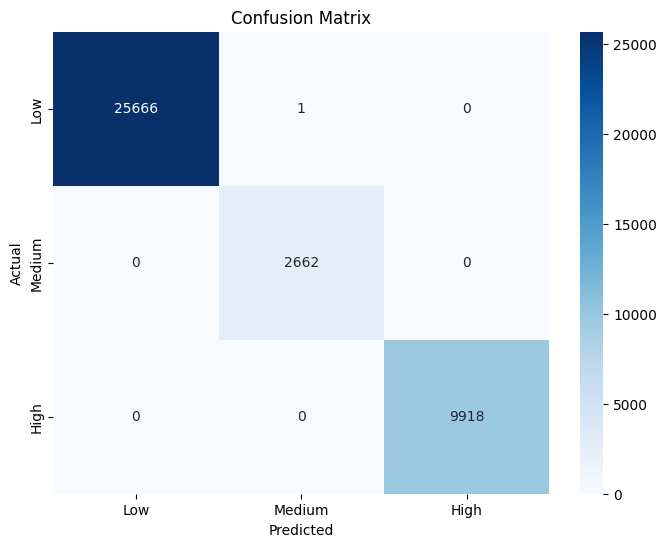


First few rows of the final dataset:
   Longitude  Latitude Category
0      -8.75     18.95      Low
1      -8.75     19.05      Low
2      -8.75     19.15      Low
3      -8.75     19.25      Low
4      -8.75     19.35      Low


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer


df = pd.read_csv("DataSet.csv")
test_df = pd.read_csv("Test_DataSet.csv")


all_seasons = pd.concat([df['season'], test_df['season']]).unique()
season_encoder = LabelEncoder()
season_encoder.fit(all_seasons)

df["Season_Encoded"] = season_encoder.transform(df["season"])
test_df["Season_Encoded"] = season_encoder.transform(test_df["season"])


df["Year"] = df["month"].apply(lambda x: int(x.split("_")[1]))
df["Month"] = df["month"].apply(lambda x: int(x.split("_")[0]))
test_df["Year"] = test_df["month"].apply(lambda x: int(x.split("_")[1]))
test_df["Month"] = test_df["month"].apply(lambda x: int(x.split("_")[0]))


df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12)
test_df['Month_sin'] = np.sin(2 * np.pi * test_df['Month']/12)
test_df['Month_cos'] = np.cos(2 * np.pi * test_df['Month']/12)


pivot_df = df.pivot_table(index=["Longitude", "Latitude"],
                         columns="Month",
                         values="Precipitation_Cleaned",
                         aggfunc='mean').reset_index()
train_months = sorted(df["Month"].unique())
pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in train_months]

test_pivot_df = test_df.pivot_table(index=["Longitude", "Latitude"],
                                   columns="Month",
                                   values="Precipitation_Cleaned",
                                   aggfunc='mean').reset_index()
test_months = sorted(test_df["Month"].unique())
test_pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in test_months]


pivot_df['Distance_From_Equator'] = abs(pivot_df['Latitude'])
test_pivot_df['Distance_From_Equator'] = abs(test_pivot_df['Latitude'])


season_data = df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()
test_season_data = test_df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()


final_df = pivot_df.merge(season_data, on=["Longitude", "Latitude"])
final_test_df = test_pivot_df.merge(test_season_data, on=["Longitude", "Latitude"])


imputer = SimpleImputer(strategy='mean')
train_month_cols = [col for col in pivot_df.columns if col.startswith("Month_")]
test_month_cols = [col for col in test_pivot_df.columns if col.startswith("Month_")]
final_df[train_month_cols] = imputer.fit_transform(final_df[train_month_cols])
final_test_df[test_month_cols] = imputer.transform(final_test_df[test_month_cols])


final_df['Mean_Precipitation'] = final_df[train_month_cols].mean(axis=1)
final_test_df['Mean_Precipitation'] = final_test_df[test_month_cols].mean(axis=1)


final_df["Total_Precipitation"] = final_df[train_month_cols].sum(axis=1)
final_test_df["Total_Precipitation"] = final_test_df[test_month_cols].sum(axis=1)


low_threshold = final_df["Total_Precipitation"].quantile(0.33)
high_threshold = final_df["Total_Precipitation"].quantile(0.66)

def categorize_rainfall(value):
    if value <= low_threshold:
        return 0
    elif value <= high_threshold:
        return 1
    else:
        return 2

final_df["Rainfall_Category"] = final_df["Total_Precipitation"].apply(categorize_rainfall)
final_test_df["Rainfall_Category"] = final_test_df["Total_Precipitation"].apply(categorize_rainfall)


common_features = ["Longitude", "Latitude", "Season_Encoded",
                  "Distance_From_Equator", "Mean_Precipitation"] + list(set(train_month_cols) & set(test_month_cols))

X_train = final_df[common_features]
y_train = final_df["Rainfall_Category"]
X_test = final_test_df[common_features]
y_test = final_test_df["Rainfall_Category"]


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)


train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))


plt.figure(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


final_dataset = pd.DataFrame({
    'Longitude': final_test_df['Longitude'],
    'Latitude': final_test_df['Latitude'],
    'Category': y_test_pred
})


category_map = {0: 'Low', 1: 'Medium', 2: 'High'}
final_dataset['Category'] = final_dataset['Category'].map(category_map)


final_dataset.to_csv('Agricultural_lands_classification.csv', index=False)


print("\nFirst few rows of the final dataset:")
print(final_dataset.head())

Our final dataset is a one in which we have only three (03) attributes, **Longtude**, **latitude**, **category**. The category will hod one of the 03: **low**, **medium** and **high**.

The final dataset will be used to look out the methods and agricultural solutions for the lands based on their rainfull level.

We have talked about to treat each based on its category, on **the conclusion impacts notebook**!